In [2]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import seaborn as sns

# Twitter Emotions Analysis

In [3]:
T_train = pd.read_csv("TwitterEmotions/training.csv")
T_test = pd.read_csv("TwitterEmotions/test.csv")

# Combine train and test into one dataframe
T_all = pd.concat(
    [T_train, T_test],
    ignore_index=True
)

Here is a method that can be used for cleaning text by removing noise such as stopwords.

In [4]:
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "im", "ive", "dont", "didnt", "doesnt", "cant", "couldnt",
    "wouldnt", "isnt", "arent", "wasnt", "werent",
    "feel", "feeling", "felt", "like", "just", "really",
    "know", "time", "people", "day", "going", "want"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()

    words = [
        word for word in words
        if word not in custom_stopwords and len(word) > 2
    ]

    return words

In [5]:
T_emotion_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

T_emotion_cols = ["sadness", "joy", "love", "anger", "fear", "surprise"]

T_all["emotion"] = T_all["label"].map(T_emotion_map)

#sns.set_theme(style="whitegrid")

In [6]:
print("Total samples in Twitter train:", len(T_all))

Total samples in Twitter train: 18000


## RQ 3. Which emotions are most and least represented in the dataset? (Emotion Frequency Distribution)


In this section we want to see the frequency of each emotion label.

In [13]:
T_emotion_freq = (
    T_all["emotion"]
    .value_counts()
    .reset_index()
)

T_emotion_freq.columns = ["Emotion", "Count"]
T_emotion_freq["Percent"] = (
    T_emotion_freq["Count"] / len(T_all) * 100
).round(2)

T_emotion_freq

,Emotion,Count,Percent
0,joy,6057,33.65
1,sadness,5247,29.15
2,anger,2434,13.52
3,fear,2161,12.01
4,love,1463,8.13
5,surprise,638,3.54


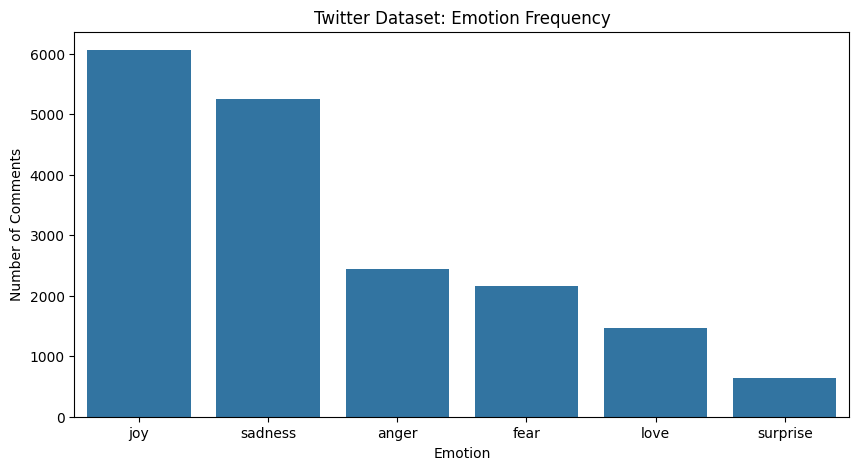

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=T_emotion_freq,
    x="Emotion",
    y="Count"
)

plt.title("Twitter Dataset: Emotion Frequency")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")

plt.show()

## RQ 5. Which words are most strongly associated with each emotion category? (Most common words per emotion)

In this section we want to see what kinds of words are most commonly associated with each emotion label in the dataset.

In [15]:
T_summary_rows = []

for emotion in sorted(T_all["emotion"].unique()):

    emotion_texts = T_all.loc[
        T_all["emotion"] == emotion,
        "text"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(10)
    ]

    T_summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })
pd.set_option('display.max_colwidth', None)

T_emotion_word_table = pd.DataFrame(T_summary_rows)

T_emotion_word_table

,Emotion,Most Common Words
0,anger,"[little, things, angry, think, way, bit, don, cold, irritable, greedy]"
1,fear,"[little, bit, strange, nervous, anxious, think, terrified, afraid, scared, weird]"
2,joy,"[make, think, good, life, little, pretty, love, happy, things, way]"
3,love,"[love, loving, sweet, passionate, caring, sympathetic, life, liked, little, hot]"
4,sadness,"[little, life, bit, think, things, make, way, don, pretty, love]"
5,surprise,"[amazed, impressed, overwhelmed, curious, weird, surprised, strange, funny, little, amazing]"


## RQ 4. Do emotions appear differently in comments referencing males versus females? (Pronoun-Based Gender Comparison)

This section aims to compare the emotion labels assigned to the male and female gender. The genders are inferred by checking whether the text contains only male or only female pronouns. 

In [26]:
T_male_mask = T_all["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )

T_female_mask = T_all["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )

T_male_comments = T_all[T_male_mask & ~T_female_mask]
T_female_comments = T_all[T_female_mask & ~T_male_mask]

/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_52338/2562667753.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_male_mask = T_all["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_52338/2562667753.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_female_mask = T_all["text"].str.contains(


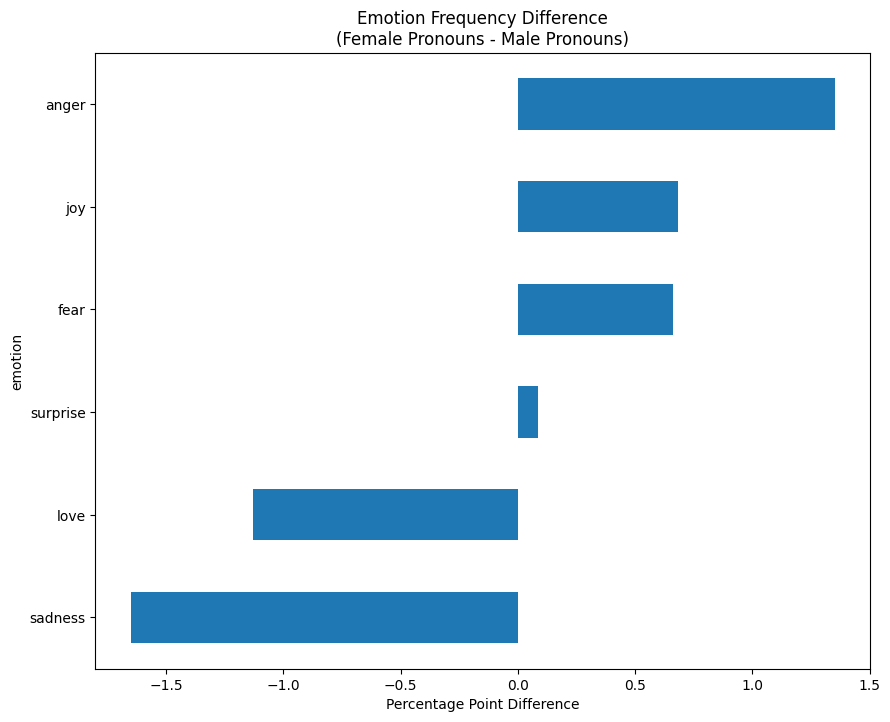

In [27]:
T_male_pct = (
    T_male_comments["emotion"]
    .value_counts(normalize=True)
    * 100
)

T_female_pct = (
    T_female_comments["emotion"]
    .value_counts(normalize=True)
    * 100
)

T_comparison = pd.DataFrame({
    "Male %": T_male_pct,
    "Female %": T_female_pct
}).fillna(0)

T_comparison["Difference"] = (
    T_comparison["Female %"] - T_comparison["Male %"]
)

T_comparison = T_comparison.sort_values(
    "Difference",
    ascending=False
)

T_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.show()

In [21]:
T_comparison

,Male %,Female %,Difference
emotion,,,
joy,28.542714,31.065089,2.522375
anger,15.678392,15.976331,0.297939
surprise,3.718593,3.550296,-0.168297
fear,11.155779,10.946746,-0.209033
love,12.060302,11.390533,-0.669769
sadness,28.844221,27.071006,-1.773215


## Text Analysis

In this section we will be conducting text analysis on the comments. This includes looking at all the unique words in the data (referred to as vocabulary size), the total number of words, and lexical richness, which is the number of unique words divided by the total words. 

In [18]:
T_all_words = []

for text in T_all["text"]:
    T_all_words.extend(clean_text(text))

T_vocab_size = len(set(T_all_words))
T_total_words = len(T_all_words)

T_lexical_richness = T_vocab_size / T_total_words

In [23]:
T_diversity_summary = pd.DataFrame({
    "Metric": [
        "Total Words",
        "Vocabulary Size",
        "Lexical Richness"
    ],
    "Value": [
        T_total_words,
        T_vocab_size,
        T_lexical_richness
    ]
})

T_diversity_summary

,Metric,Value
0,Total Words,104152.000000
1,Vocabulary Size,14697.000000
2,Lexical Richness,0.141111


I re-conducted this analysis for each emotion label.

In [19]:
T_diversity_rows = []

for emotion in T_emotion_cols:

    emotion_texts = T_all.loc[
        T_all["emotion"] == emotion,
        "text"
    ]

    words = []

    for text in emotion_texts:
        words.extend(clean_text(text))

    total_words = len(words)
    unique_words = len(set(words))

    lexical_richness = (
        unique_words / total_words
        if total_words > 0 else 0
    )

    T_diversity_rows.append({
        "Emotion": emotion,
        "Sample Count": len(emotion_texts),
        "Total Words": total_words,
        "Vocabulary Size": unique_words,
        "Lexical Richness": lexical_richness
    })

T_diversity_table = pd.DataFrame(T_diversity_rows)

T_diversity_table = T_diversity_table.sort_values(
    "Lexical Richness",
    ascending=False
)

T_diversity_table

,Emotion,Sample Count,Total Words,Vocabulary Size,Lexical Richness
5,surprise,638,4395,2031,0.462116
2,love,1463,10199,3760,0.368664
4,fear,2161,13839,4319,0.312089
3,anger,2434,15735,4834,0.307213
1,joy,6057,40307,8842,0.219366
0,sadness,5247,32571,7112,0.218354


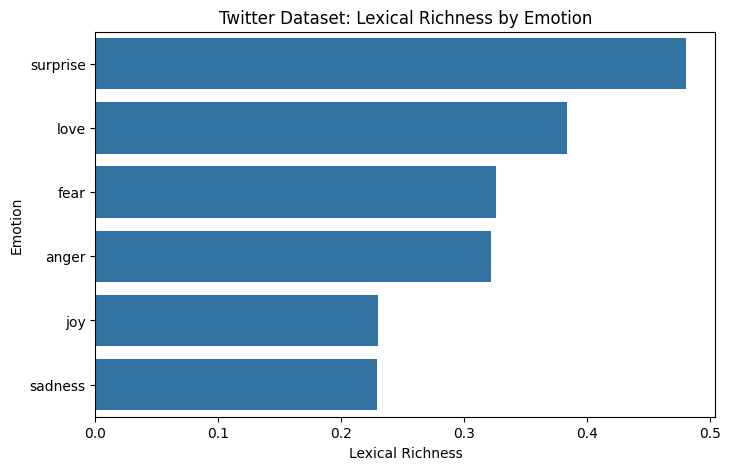

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=T_diversity_table,
    y="Emotion",
    x="Lexical Richness"
)

plt.title("Twitter Dataset: Lexical Richness by Emotion")
plt.xlabel("Lexical Richness")
plt.ylabel("Emotion")
plt.show()

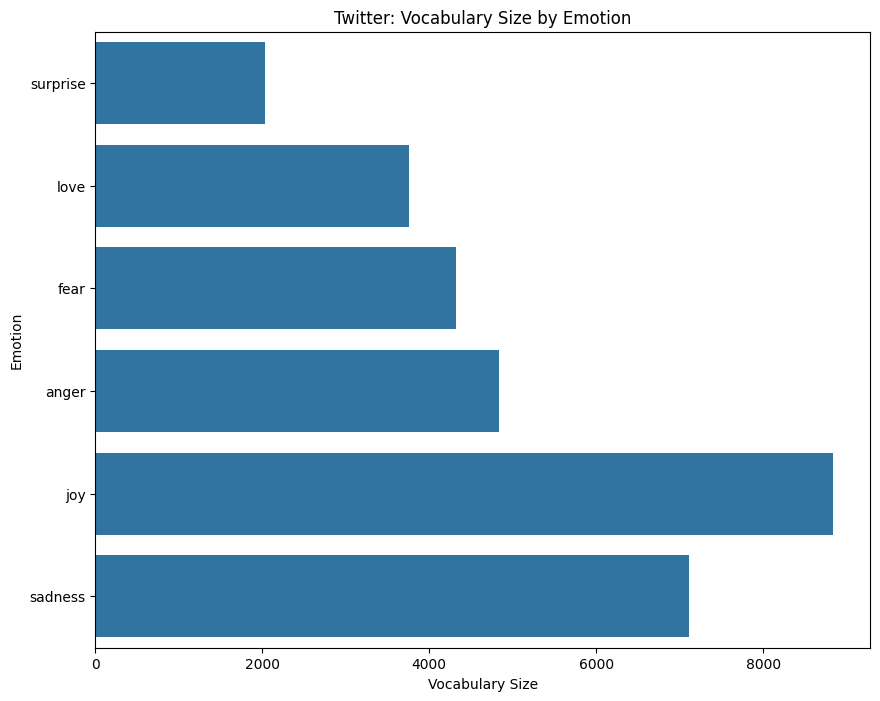

In [30]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=T_diversity_table,
    y="Emotion",
    x="Vocabulary Size"
)

plt.title("Twitter: Vocabulary Size by Emotion")
plt.xlabel("Vocabulary Size")
plt.ylabel("Emotion")
plt.show()

## Distribution of Comment Length

This is mainly to see the distribution of comment length. How many comments are long/medium/short?

In [20]:
T_all["word_count"] = T_all["text"].apply(
    lambda text: len(str(text).split())
)

T_all["clean_word_count"] = T_all["text"].apply(
    lambda text: len(clean_text(text))
)

T_all["char_count"] = T_all["text"].apply(
    lambda text: len(str(text))
)

In [21]:
print("Average raw words:",
      T_all["word_count"].mean())

print("Median raw words:",
      T_all["word_count"].median())

print("Average cleaned words:",
      T_all["clean_word_count"].mean())

print("Median cleaned words:",
      T_all["clean_word_count"].median())

print("Average characters:",
      T_all["char_count"].mean())

Average raw words: 19.164944444444444
Median raw words: 17.0
Average cleaned words: 6.502555555555555
Median cleaned words: 6.0
Average characters: 96.817


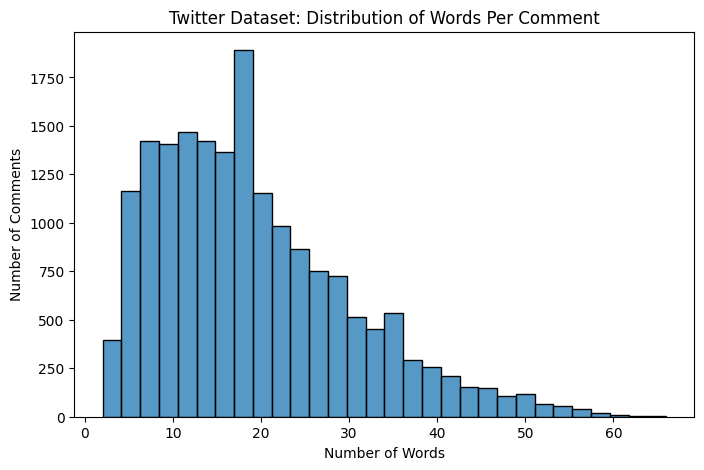

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    T_all["word_count"],
    bins=30
)

plt.title("Twitter Dataset: Distribution of Words Per Comment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.show()

## Emotion vs Comment Length

I conducted that same analysis across each emotion label. What emotions tend to have comments that are longer in length? I decided to observe this trend across both cleaned and non-cleaned comments.

In [23]:
T_length_table = (
    T_all.groupby("emotion")
    .agg(
        Avg_Words=("word_count", "mean"),
        Median_Words=("word_count", "median"),
        Avg_Cleaned_Words=("clean_word_count", "mean"),
        Median_Cleaned_Words=("clean_word_count", "median"),
        Avg_Characters=("char_count", "mean"),
        Samples=("emotion", "count")
    )
    .sort_values("Avg_Words", ascending=False)
)

In [28]:
T_length_table

,Avg_Words,Median_Words,Avg_Cleaned_Words,Median_Cleaned_Words,Avg_Characters,Samples
emotion,,,,,,
love,20.619275,19.0,6.971292,6.0,103.755297,1463
surprise,19.948276,18.0,6.888715,6.0,101.487461,638
joy,19.469374,18.0,6.654614,6.0,98.379231,6057
anger,19.253081,17.0,6.464667,6.0,97.079704,2434
fear,18.763998,16.0,6.403980,5.0,95.730680,2161
sadness,18.437012,16.0,6.207547,5.0,92.836669,5247


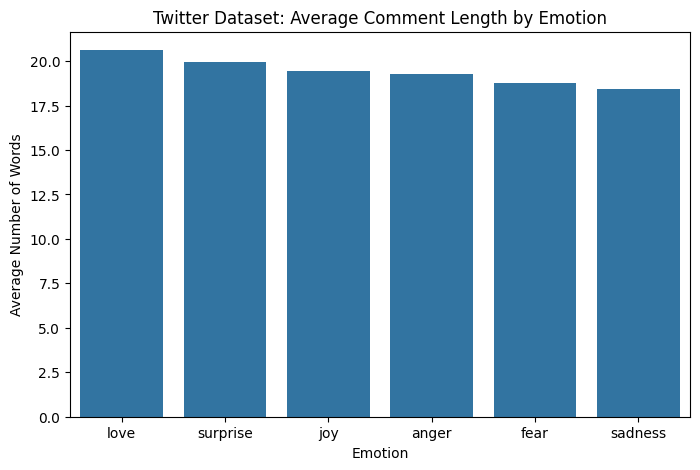

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=T_length_table.reset_index(),
    x="emotion",
    y="Avg_Words"
)

plt.title("Twitter Dataset: Average Comment Length by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Number of Words")
plt.show()

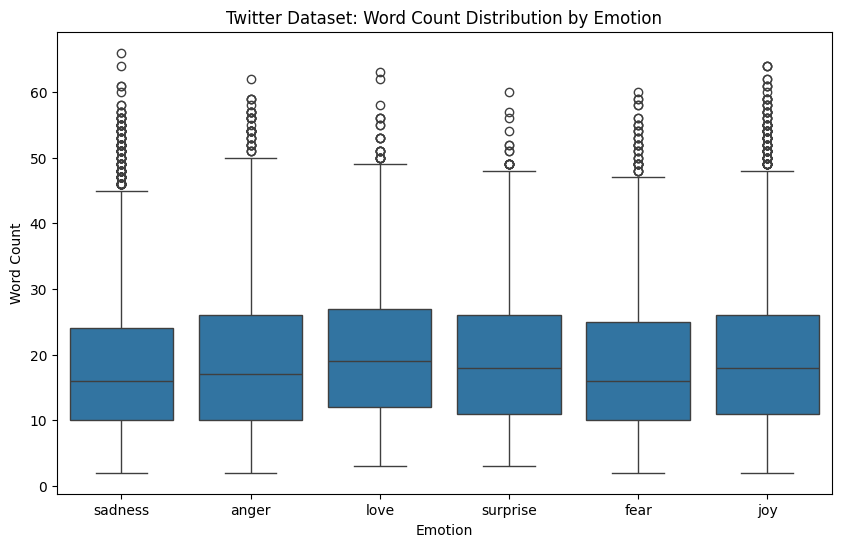

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=T_all,
    x="emotion",
    y="word_count"
)

plt.title("Twitter Dataset: Word Count Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Word Count")
plt.show()